## Peak performance comparison between Multi-core Scan and `torch.clone` copy operator

> The goal is to understand the "peak performance" of Ascend for a simple element-wise operator like `copy` (copy-in and copy-out). We can use this benchmark as the practical peak performance of Ascend.

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context('paper', font_scale=2., rc={"lines.linewidth": 1.75} )
sns.set_style({'font.weight': 'bold'})

# Markers
plt.rcParams['lines.markersize'] = 6.5
plt.rcParams['lines.linewidth'] = 1.75
plt.rcParams['figure.figsize'] = (8.7,6.27)

_LEGEND_MARKER_SCALE = 1.75
_MARKERS = ["o", "^", "s", "X"]

_SNS_PARAMS = {"hue":'S', "style":'S', "markers":_MARKERS, "dashes":True}


In [22]:
# Select plot parameters

# dtype = "int8"
dtype = "fp16"
tiles = [32, 64, 128]

In [23]:
def add_stats_siso(df, nbytes_out_dtype: int):
    # Input number of bytes per element
    df["in_bytes_per_elem"] = df["dtype"].map({"fp16": 2, "int8": 1})

    df["mem_bytes"] = df["size"] * (df["in_bytes_per_elem"] + nbytes_out_dtype)
    
    df["gelemps"] = (df["size"] / 1e9) / (df["time_us"] / 1e6)
    df["bw_gbps"] = ( df["mem_bytes"] / 1e9) / (df["time_us"] / 1e6)

In [24]:
PREFIX_PATH = "../../.."

df_copy = pd.read_csv(f"{PREFIX_PATH}/bench_results_copy_{dtype}.csv")
df_copy["S"] = "memcopy (fp16)"
add_stats_siso(df_copy, 2)


df_cast = pd.read_csv(f"{PREFIX_PATH}/bench_results_cast_{dtype}.csv")
df_cast["S"] = "cast (fp16->32)"
add_stats_siso(df_cast, 4)


df_tiled = pd.DataFrame()
for tile in tiles:
    df_tmp = pd.read_csv(f"{PREFIX_PATH}/bench_results_mcscan_{tile}_{dtype}.csv")
    df_tmp["S"] = f"s={tile}"
    df_tiled = pd.concat([df_tiled, df_tmp])

add_stats_siso(df_tiled, 4)

df = pd.concat([df_copy, df_cast, df_tiled])

## Paper plots

/tmp/ipykernel_2004287/3668118024.py:1: UserWarning: 
The markers list has fewer values (4) than needed (5) and will cycle, which may produce an uninterpretable plot.
  ax = sns.lineplot(data=df, x='size', y='gelemps', **_SNS_PARAMS)


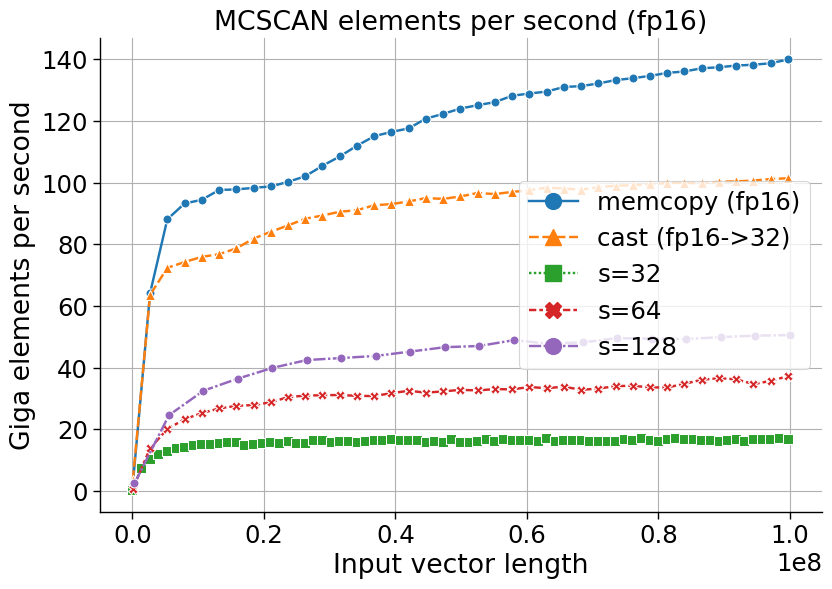

<Figure size 870x627 with 0 Axes>

In [ ]:
ax = sns.lineplot(data=df, x='size', y='gelemps', **_SNS_PARAMS)

ax.set_title(f"MCSCAN elements per second ({dtype})")
ax.set_xlabel("Input vector length")
ax.set_ylabel("Giga elements per second")
sns.despine(right = True)
plt.legend(markerscale=_LEGEND_MARKER_SCALE)
plt.grid()
plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"figs/mcscan_gelemsps_{dtype}.png")
plt.show()
plt.clf()

/tmp/ipykernel_2004287/3772505010.py:1: UserWarning: 
The markers list has fewer values (4) than needed (5) and will cycle, which may produce an uninterpretable plot.
  ax = sns.lineplot(data=df, x='size', y='bw_gbps', **_SNS_PARAMS)


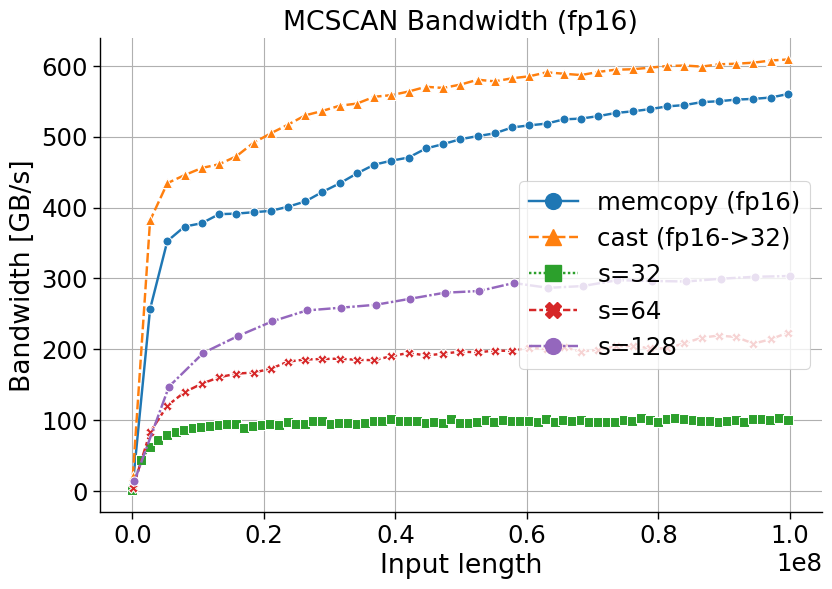

<Figure size 870x627 with 0 Axes>

In [ ]:
ax = sns.lineplot(data=df, x='size', y='bw_gbps', **_SNS_PARAMS)

ax.set_title(f"MCSCAN Bandwidth ({dtype})")
ax.set_xlabel("Input length")
ax.set_ylabel("Bandwidth [GB/s]")
sns.despine(right = True)
plt.legend(markerscale=_LEGEND_MARKER_SCALE)
plt.grid()

plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"figs/mcscan_bw_{dtype}.png")
plt.show()
plt.clf()


In [27]:
df.head(100)

,operator,dtype,size,density,outputsize,time_us,S,in_bytes_per_elem,mem_bytes,gelemps,bw_gbps
0,copy,fp16,81920,None,81920,35.98,memcopy (fp16),2,327680,2.276820,9.107282
1,copy,fp16,2703360,None,2703360,42.11,memcopy (fp16),2,10813440,64.197578,256.790311
2,copy,fp16,5324800,None,5324800,60.41,memcopy (fp16),2,21299200,88.144347,352.577388
3,copy,fp16,7946240,None,7946240,85.19,memcopy (fp16),2,31784960,93.276676,373.106703
4,copy,fp16,10567680,None,10567680,111.87,memcopy (fp16),2,42270720,94.463931,377.855725
...,...,...,...,...,...,...,...,...,...,...,...
17,mcscan_32,fp16,22302720,None,22302720,1428.67,s=32,2,133816320,15.610827,93.664961
18,mcscan_32,fp16,23613440,None,23613440,1459.32,s=32,2,141680640,16.181125,97.086753
19,mcscan_32,fp16,24924160,None,24924160,1588.37,s=32,2,149544960,15.691659,94.149952
20,mcscan_32,fp16,26234880,None,26234880,1670.84,s=32,2,157409280,15.701611,94.209667


In [28]:
max_size = df["size"].max()
df[df["size"] >= 99 * 1e6].head(20)

,operator,dtype,size,density,outputsize,time_us,S,in_bytes_per_elem,mem_bytes,gelemps,bw_gbps
38,copy,fp16,99696640,None,99696640,712.11,memcopy (fp16),2,398786560,140.001741,560.006965
38,cast,fp16,99696640,None,99696640,982.64,cast (fp16->32),2,598179840,101.457950,608.747700
76,mcscan_32,fp16,99635200,None,99635200,5922.25,s=32,2,597811200,16.823876,100.943256
38,mcscan_64,fp16,99696640,None,99696640,2675.40,s=64,2,598179840,37.264200,223.585198
19,mcscan_128,fp16,99942400,None,99942400,1976.68,s=128,2,599654400,50.560738,303.364429
